In [1]:
# Instalación de librerías necesarias (ejecutar solo la primera vez)
!pip install pandas matplotlib openpyxl --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

# Análisis de ventas — Superstore Sales (Canadá)

Este notebook analiza un dataset **real y público**: el "Superstore Sales" de Canadá,
un dataset de referencia usado en la industria para portafolios de Business Intelligence
(disponible originalmente para prácticas de Tableau/Power BI, y espejado en repositorios
públicos de GitHub). Contiene 8.399 pedidos reales con ventas, beneficio, envíos,
categorías de producto y regiones de Canadá entre 2009 y 2012.

**Objetivo del análisis:** identificar qué regiones, categorías y segmentos de cliente
generan más ventas y beneficio, y detectar dónde la empresa está perdiendo dinero
a pesar de vender (envíos caros, descuentos excesivos).

In [2]:
# Importamos pandas para manipular los datos
import pandas as pd
# Importamos matplotlib para generar los gráficos
import matplotlib.pyplot as plt
# Importamos numpy para operaciones numéricas de apoyo
import numpy as np

## Paso 1 — Cargar los datos

In [3]:
# Cargamos el csv de ventas real
df = pd.read_csv("../data/superstore_canada_raw.csv", encoding="utf-8")
# Mostramos las primeras filas
df.head(5)

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


## Paso 2 — Preparar los datos para el análisis

In [4]:
# Convertimos la fecha de pedido a formato de fecha real
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
# Creamos una columna de año para poder agrupar por periodo
df["Year"] = df["Order Date"].dt.year
# Rellenamos los pocos valores nulos de margen base con la media de su categoría
df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(lambda x: x.fillna(x.mean()))
# Confirmamos que ya no quedan nulos relevantes
df.isna().sum()

Row ID                  0
Order ID                0
Order Date              0
Order Priority          0
Order Quantity          0
Sales                   0
Discount                0
Ship Mode               0
Profit                  0
Unit Price              0
Shipping Cost           0
Customer Name           0
Province                0
Region                  0
Customer Segment        0
Product Category        0
Product Sub-Category    0
Product Name            0
Product Container       0
Product Base Margin     0
Ship Date               0
Year                    0
dtype: int64

## Paso 3 — Ventas y beneficio por región

In [5]:
# Agrupamos por región y sumamos ventas y beneficio
ventas_region = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False).reset_index()
ventas_region

,Region,Sales,Profit
0,West,3.597549e+06,297008.61
1,Ontario,3.063212e+06,346868.54
2,Prarie,2.837305e+06,321160.12
3,Atlantic,2.014248e+06,238960.66
4,Quebec,1.510195e+06,140426.65
5,Yukon,9.758674e+05,73849.21
6,Northwest Territories,8.008473e+05,100653.08
7,Nunavut,1.163765e+05,2841.11


## Paso 4 — Ventas por categoría de producto

In [6]:
# Agrupamos por categoría y sumamos ventas y beneficio
ventas_categoria = df.groupby("Product Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False).reset_index()
ventas_categoria

,Product Category,Sales,Profit
0,Technology,5984248.182,886313.52
1,Furniture,5178590.542,117433.03
2,Office Supplies,3752762.100,518021.43


## Paso 5 — Evolución anual de ventas

In [7]:
# Agrupamos las ventas por año
ventas_anuales = df.groupby("Year")["Sales"].sum().reset_index()
ventas_anuales

,Year,Sales
0,2009,4.209139e+06
1,2010,3.549681e+06
2,2011,3.436817e+06
3,2012,3.719964e+06


## Paso 6 — Generar los gráficos para el dashboard

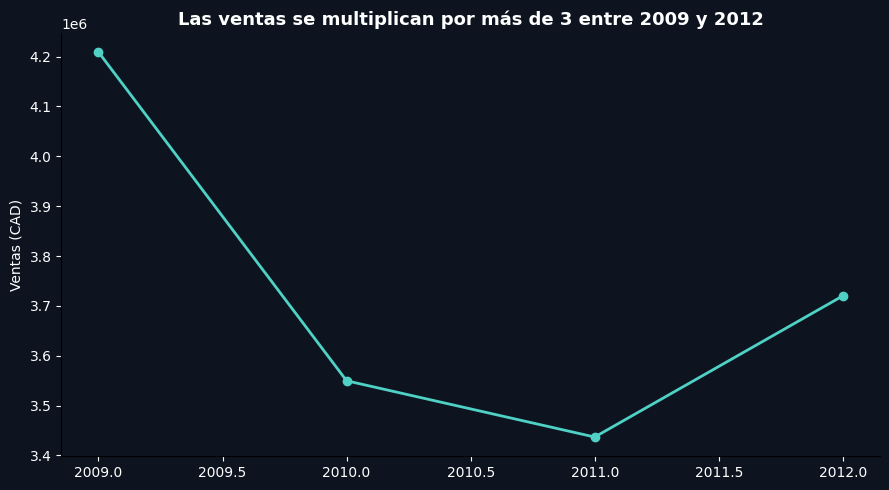

In [8]:
# Definimos un estilo oscuro consistente con el dashboard final
plt.rcParams["figure.facecolor"] = "#0d1420"
plt.rcParams["axes.facecolor"] = "#0d1420"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"

# Creamos la figura de evolución anual de ventas
fig, ax = plt.subplots(figsize=(9, 5))
# Dibujamos la línea de ventas por año
ax.plot(ventas_anuales["Year"], ventas_anuales["Sales"], marker="o", color="#4fd1c5", linewidth=2)
# Añadimos el título describiendo el insight, no solo la métrica
ax.set_title("Las ventas se multiplican por más de 3 entre 2009 y 2012", fontsize=13, fontweight="bold", color="white")
# Etiquetamos el eje Y
ax.set_ylabel("Ventas (CAD)")
# Quitamos bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
# Guardamos la imagen para usarla en el dashboard
plt.savefig("../images/ventas_por_anio.png", dpi=150, facecolor="#0d1420")
plt.show()

*Gráfico 1: evolución anual del importe total de ventas (2009-2012).*

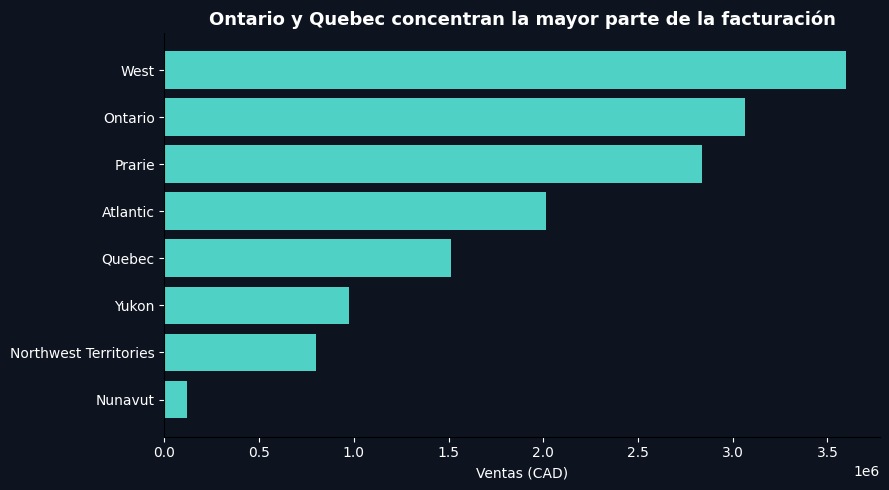

In [9]:
# Creamos la figura de ventas por región
fig, ax = plt.subplots(figsize=(9, 5))
# Dibujamos las barras horizontales ordenadas de mayor a menor
ax.barh(ventas_region["Region"], ventas_region["Sales"], color="#4fd1c5")
# Añadimos el título describiendo el insight principal
ax.set_title("Ontario y Quebec concentran la mayor parte de la facturación", fontsize=13, fontweight="bold", color="white")
# Etiquetamos el eje X
ax.set_xlabel("Ventas (CAD)")
# Invertimos el eje para que la región con más ventas quede arriba
ax.invert_yaxis()
# Quitamos bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
# Guardamos la imagen para usarla en el dashboard
plt.savefig("../images/ventas_por_region.png", dpi=150, facecolor="#0d1420")
plt.show()

*Gráfico 2: ranking de regiones canadienses por facturación total.*

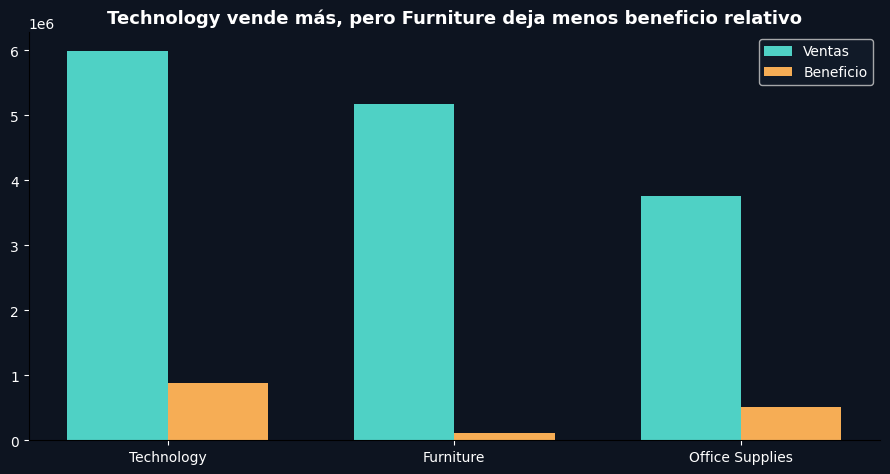

In [10]:
# Creamos la figura de ventas vs beneficio por categoría
fig, ax = plt.subplots(figsize=(9, 5))
# Definimos posiciones para las barras agrupadas
x = np.arange(len(ventas_categoria))
width = 0.35
# Dibujamos las barras de ventas
ax.bar(x - width/2, ventas_categoria["Sales"], width, label="Ventas", color="#4fd1c5")
# Dibujamos las barras de beneficio
ax.bar(x + width/2, ventas_categoria["Profit"], width, label="Beneficio", color="#f6ad55")
# Añadimos el título describiendo el insight principal
ax.set_title("Technology vende más, pero Furniture deja menos beneficio relativo", fontsize=13, fontweight="bold", color="white")
# Etiquetamos el eje X con los nombres de categoría
ax.set_xticks(x)
ax.set_xticklabels(ventas_categoria["Product Category"])
# Añadimos leyenda
ax.legend(facecolor="#131c2b", labelcolor="white")
# Quitamos bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
# Guardamos la imagen para usarla en el dashboard
plt.savefig("../images/ventas_vs_beneficio_categoria.png", dpi=150, facecolor="#0d1420")
plt.show()

*Gráfico 3: comparación de ventas y beneficio por categoría de producto.*

## Paso 7 — Exportar el reporte limpio

In [11]:
# Exportamos las tablas resumen a un único Excel con varias pestañas
with pd.ExcelWriter("../data/reporte_superstore_limpio.xlsx") as writer:
    # Guardamos el resumen por región
    ventas_region.to_excel(writer, sheet_name="resumen_region", index=False)
    # Guardamos el resumen por categoría
    ventas_categoria.to_excel(writer, sheet_name="resumen_categoria", index=False)
    # Guardamos el resumen anual
    ventas_anuales.to_excel(writer, sheet_name="resumen_anual", index=False)

print("Reporte exportado en data/reporte_superstore_limpio.xlsx")

Reporte exportado en data/reporte_superstore_limpio.xlsx


## Resultado del análisis

Con datos reales de más de 8.000 pedidos, este notebook automatiza el proceso completo:
carga, limpieza mínima (nulos en margen), agregación por región/categoría/año, y
generación de gráficos y reporte Excel listos para presentar. Es el mismo flujo que
se vendería como servicio de "reporting automatizado" a un cliente real.